# ini

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # allow importing from parent directory
from fun_gilles import *
import pickle
import pandas as pd

In [3]:
colors = plt.get_cmap('Set2').colors
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]=False
import matplotlib.pyplot as plt

# Fine-tune specific elements
plt.rcParams['font.size'] = 12          # Global default
plt.rcParams['axes.titlesize'] = 15     # Individual subplot titles
plt.rcParams['axes.labelsize'] = 15     # x and y labels
plt.rcParams['xtick.labelsize'] = 14    # x-axis tick numbers
plt.rcParams['ytick.labelsize'] = 14    # y-axis tick numbers
plt.rcParams['legend.fontsize'] = 13    # Legend text
plt.rcParams['figure.titlesize'] = 16   # Figure suptitle

In [4]:
def plot(abundances, times, V, species,fig_name=None, xlim = None):
    """
    Plot de la variación en la concentración y en el volumen
    """

    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True) 

    # --- Subplot 1 (Left): Concentration ---
    ax1 = axes[0]
    for i in range(len(species)):
        # Calculate Concentration = Abundance / Volume
        ax1.plot(times, abundances[:, i] / V, label=species[i], color=colors[i], alpha=0.9)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Concentration")
    ax1.set_title("Concentration Evolution")
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.4), title="Species")

    # --- Subplot 2 (Middle): Volume ---
    ax2 = axes[1]
    ax2.plot(times, V, color='gray')
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Volume")
    # ax2.set_yscale("log")
    ax2.set_title("Volume Evolution")
    
    if xlim != None:
        ax1.set_xlim((0,xlim))
        ax2.set_xlim((0,xlim))
   
    # Adjust layout to prevent labels/titles from overlapping
    plt.tight_layout(rect=[0, 0, 1, 1])
    if fig_name != None:
        plt.savefig(f"{fig_name}.png")
    plt.show()

In [5]:
def plot_conc(abundances, times, V, species, fig_name=None, xlim = None):
    """
    Plot de la variación en la concentración
    """

    fig, axes = plt.subplots(figsize= (7,3)) 
    ax1 = axes
    # --- Subplot 1 (Left): Concentration ---
    for i in range(len(species)):
        # Calculate Concentration = Abundance / Volume
        ax1.plot(times, abundances[:, i] / V, label=species[i], color=colors[i], alpha=0.9)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Concentration")
    ax1.set_title("Concentration Evolution")
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Species")
    # Adjust layout to prevent labels/titles from overlapping
    plt.tight_layout(rect=[0, 0, 1, 1])
    if xlim != None:
        ax1.set_xlim((0,xlim))    
    if fig_name != None:
        plt.savefig(f"{fig_name}.png")

    plt.show()

# Figure 1

In [5]:
xyc_file = "../examples/reactions_XYC.txt"
xyc_species= ["c","x", "y", "xc", "xy"]
a_xyc, t_xyc, v_xyc = chemistry(method= "Gillespie",
                                iterations= 3e4,
                                file= xyc_file,
                                initial_food= [100, 1000, 1000, 0, 0],
                                k= [1]* 4,
                                V= 1000)


Criterion for stop was # of iterations


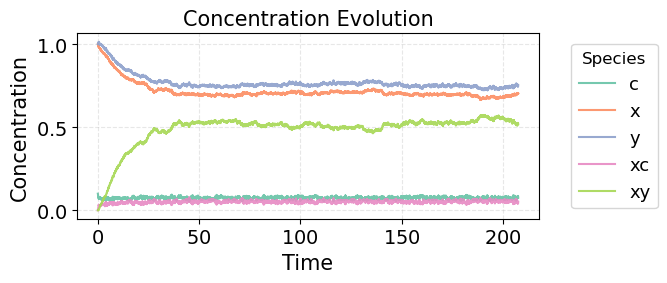

In [6]:
plot_conc(a_xyc, t_xyc, v_xyc, xyc_species, fig_name= "XYC_time_evolution")

In [6]:
f= "../examples/reactions_autocat.txt"
species= obtain_species(read_file(f))
a, t, v= chemistry(method= "Protocell",
                   file=f,
                   iterations= 1e5,
                   initial_food=[1000]*4 + [1000]*1 + [0]*3,
                   k = [1]*8,
                   V= 1000)

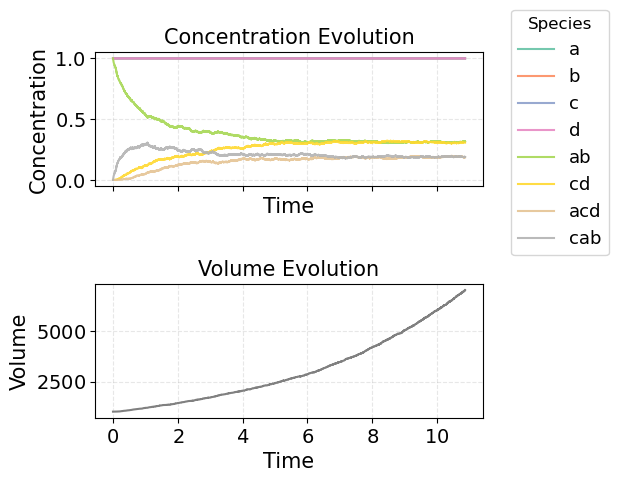

In [7]:
plot(a, t, v, species, fig_name= "autocat_time_evolution")

# Figure 2

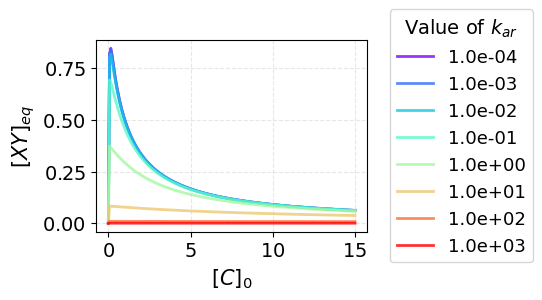

In [15]:
f = "../examples/reactions_XYC.txt" # M reactions
method = "Deterministic" # Gillespie or Deterministic

# obtener reacciones y especies:
reactions = read_file(f)
species = obtain_species(reactions)
# Reaction constants:
k = [1,0,1,1] # len(k)= # de reacciones
# Volume:
V0 = 10
initial_food = [0,10,10] + [0]*2# initial molecules number
initial_c = (np.linspace(0,150,200))
k_var = np.logspace(-4, 3, 8)
n_iterations = 1000
equilibrium = np.zeros((len(initial_c)))
colors = plt.cm.rainbow(np.linspace(0, 1, len(k_var)))
plt.figure(figsize=(3.5,2.5))
for j in range(len(k_var)):
    k[1] = k_var[j] 
    
    for i in range(len(initial_c)):
        initial_food[0] = initial_c[i]
        abundances, times, V = chemistry(method, n_iterations, f, 
                                    initial_food, k, V0)
        equilibrium[i] = abundances[-1, -1]/V0
    
    plt.plot(initial_c/V0, equilibrium, label=f"{k_var[j]:.1e}",
            color=colors[j], alpha=0.8, linewidth= 2)
        

plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel("$[C]_0$")
plt.ylabel("$[XY]_{eq}$")
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title= "Value of $k_{ar}$", title_fontsize=14)

plt.savefig("equilibrium_sweep_ar.png", bbox_inches='tight')    
plt.show()


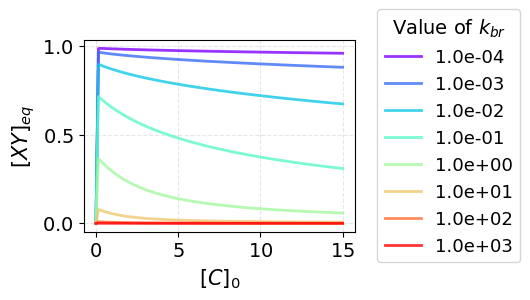

In [16]:
# Reaction constants:
k = [1,1,1,1] # len(k)= # de reacciones
# Volume:
V = 10
initial_food = [0,10,10,0,0] # initial molecules number
initial_c = (np.linspace(0,150,100))
k_var = np.logspace(-4, 3, 8)
n_iterations = 10000
equilibrium = np.zeros((len(initial_c)))
colors = plt.cm.rainbow(np.linspace(0, 1, len(k_var)))
plt.figure(figsize=(3.5,2.5))

for j in range(len(k_var)):
    k[3] = k_var[j] 
    V = V0
    for i in range(len(initial_c)):
        initial_food[0] = initial_c[i]
        abundances, times, V = chemistry(method, n_iterations, f, 
                                    initial_food, k, V0)
        equilibrium[i] = abundances[-1, -1]/V0
    
    plt.plot(initial_c/V0, equilibrium, label=f"{k_var[j]:.1e}",
            color=colors[j], alpha=0.8,linewidth=2)
        

plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel("$[C]_0$")
plt.ylabel("$[XY]_{eq}$")    
plt.tick_params(axis='both')


plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title= "Value of $k_{br}$", title_fontsize=14)
plt.savefig("equilibrium_sweep_br.png", bbox_inches='tight')    
plt.show()